## Introduction
Exploratory data analysis (EDA) plays a vital role in the data analysis process, serving as the foundation for discovering meaningful insights, patterns, and trends. Through EDA, we begin to understand the structure and behavior of data, allowing us to make more informed and confident decisions. This project provides a valuable opportunity to apply what I have learned in a practical, hands-on context that closely mirrors real-world analytics work.

By working with a dataset containing Major League Baseball (MLB) player statistics, I will engage in the full EDA cycle—from cleaning and preparing the data, to exploring distributions and relationships, to conducting statistical analysis and drawing conclusions. Each step in the process will help strengthen my ability to think critically about data and refine the techniques I have learned.

In [12]:
import pandas as pd

In [13]:
df = pd.read_csv("mlb.csv")
df.head()

,salary,player_position,race,team_payroll,years_played,games_played,career_at_bats,career_runs,career_hits,career_doubles,...,career_homeruns,career_runs_batted_in,career_batting_average,career_walks,career_strike_outs,career_stolen_bases,career_fielding_percent,white_percent_in_city,black_percent_in_city,hispanic_percent_in_city
0,3375000,shortstop,black,38407380,8,918,3333,407,863,156,...,73,342,259,137,582,133,968,70.27797,18.84423,10.8778
1,3100000,firstbase,white,38407380,5,751,2807,370,840,148,...,46,355,299,341,228,41,994,70.27797,18.84423,10.8778
2,2900000,thirdbase,white,38407380,8,1056,3337,405,816,143,...,107,421,245,306,653,15,971,70.27797,18.84423,10.8778
3,1650000,outfield,black,38407380,12,1196,3603,437,928,19,...,124,541,258,316,725,32,977,70.27797,18.84423,10.8778
4,700000,outfield,black,38407380,17,2032,7489,1136,2145,270,...,40,574,286,416,1098,660,987,70.27797,18.84423,10.8778


## 1. Generate descriptive statistics for the dataset, and comment on the main trends.

In [15]:
df.shape

(352, 21)

In [16]:
continuous_variables = df.select_dtypes(include=['float64', 'int64']).columns
continuous_variables.tolist()

['salary',
 'team_payroll',
 'years_played',
 'games_played',
 'career_at_bats',
 'career_runs',
 'career_hits',
 'career_doubles',
 'career_triples',
 'career_homeruns',
 'career_runs_batted_in',
 'career_batting_average',
 'career_walks',
 'career_strike_outs',
 'career_stolen_bases',
 'career_fielding_percent',
 'white_percent_in_city',
 'black_percent_in_city',
 'hispanic_percent_in_city']

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   salary                    352 non-null    int64  
 1   player_position           352 non-null    object 
 2   race                      352 non-null    object 
 3   team_payroll              352 non-null    int64  
 4   years_played              352 non-null    int64  
 5   games_played              352 non-null    int64  
 6   career_at_bats            352 non-null    int64  
 7   career_runs               352 non-null    int64  
 8   career_hits               352 non-null    int64  
 9   career_doubles            352 non-null    int64  
 10  career_triples            352 non-null    int64  
 11  career_homeruns           352 non-null    int64  
 12  career_runs_batted_in     352 non-null    int64  
 13  career_batting_average    352 non-null    int64  
 14  career_wal

In [18]:
df.describe()

,salary,team_payroll,years_played,games_played,career_at_bats,career_runs,career_hits,career_doubles,career_triples,career_homeruns,career_runs_batted_in,career_batting_average,career_walks,career_strike_outs,career_stolen_bases,career_fielding_percent,white_percent_in_city,black_percent_in_city,hispanic_percent_in_city
count,3.520000e+02,3.520000e+02,352.000000,352.000000,352.000000,352.000000,352.000000,352.000000,352.000000,352.000000,352.000000,352.000000,352.000000,352.000000,352.000000,352.000000,329.000000,329.000000,329.000000
mean,1.331514e+06,3.077320e+07,6.309659,645.423295,2155.704545,288.170455,580.889205,103.267045,16.590909,54.531250,263.122159,258.900568,210.926136,338.681818,65.096591,976.474432,72.638240,16.541950,10.819810
std,1.383952e+06,8.725344e+06,3.873810,536.499990,2013.393716,298.500277,571.632472,103.831374,21.395948,73.369759,281.741692,38.443636,227.191851,323.886980,112.548093,19.751430,15.249897,13.688558,9.402261
min,1.090000e+05,8.854000e+06,1.000000,7.000000,7.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,111.000000,0.000000,0.000000,0.000000,800.000000,20.296300,3.741786,0.540870
25%,2.527000e+05,2.455733e+07,3.000000,230.000000,631.500000,73.000000,163.000000,26.000000,3.000000,8.000000,59.750000,245.000000,49.750000,101.000000,4.750000,969.000000,67.668960,8.007545,1.962080
50%,6.750000e+05,3.413650e+07,6.000000,518.500000,1583.000000,190.500000,416.000000,70.000000,9.000000,26.000000,172.000000,259.000000,137.000000,235.500000,24.500000,980.500000,74.619650,14.453980,10.877800
75%,2.250000e+06,3.779200e+07,9.000000,930.000000,3026.000000,405.500000,817.250000,146.250000,23.000000,70.000000,358.000000,275.000000,304.250000,474.000000,75.000000,988.000000,82.948860,18.755630,16.330650
max,6.200000e+06,4.286600e+07,20.000000,2729.000000,10554.000000,1570.000000,3025.000000,634.000000,142.000000,432.000000,1710.000000,625.000000,1286.000000,1891.000000,1042.000000,1000.000000,94.696270,73.960030,31.037500


#### Comments:
A. Team Salaries and Payroll
- Average Salary: $1.33M


- Average Team Payroll: 30.77M with a wide range from 8.85M to 42.86M.


- 75% of players are paid under ~2.25M, while some players are paid very well (up to $6.2M).


B. Years and Matches
- Average player has 6.3 years of experience, 50% of players have less than 6 years of experience, but the top 25% have 9 years or more.
- Average 645 matches, 50% of players have less than 518 matches, while the top 25% have more than 930 matches.
- 
--> Only a few players have a long playing time and maintain a long career.

C. Player Statistics
- Distributions are right-skewed for metrics like at_bats, runs, hits, and homeruns.
- Top 25% clearly outperform in key stats like hits, runs, and home runs.
- Fielding is stable across players; batting and scoring show big performance gaps.

D. Demographic
- Some cities have a mix of all three groups, but most are still overwhelmingly white.

## 2. Check any records with missing values and handle the missing data as appropriate.

In [21]:
# Show the number of missing values in each column
missing_data = df.isnull().sum()

# Filter out columns with missing values
missing_data = missing_data[missing_data > 0]

# Show results
if not missing_data.empty:
    print("Missing Data:")
    print(missing_data)
else:
    print("No missing data found in the dataset.")

Missing Data:
white_percent_in_city       23
black_percent_in_city       23
hispanic_percent_in_city    23
dtype: int64


In [22]:
# Handle missing data by filling in the average value of each column
df.fillna({
    "white_percent_in_city": df["white_percent_in_city"].mean(),
    "black_percent_in_city": df["black_percent_in_city"].mean(),
    "hispanic_percent_in_city": df["hispanic_percent_in_city"].mean()
}, inplace=True)

# Check for missing data
missing_data_after = df.isnull().sum()

missing_data_after

salary                      0
player_position             0
race                        0
team_payroll                0
years_played                0
games_played                0
career_at_bats              0
career_runs                 0
career_hits                 0
career_doubles              0
career_triples              0
career_homeruns             0
career_runs_batted_in       0
career_batting_average      0
career_walks                0
career_strike_outs          0
career_stolen_bases         0
career_fielding_percent     0
white_percent_in_city       0
black_percent_in_city       0
hispanic_percent_in_city    0
dtype: int64

3. Build graphs visualizing the following and comment on the obtained visual insights

### A. The distribution of one or more individual continuous variables

<Figure size 1200x800 with 0 Axes>

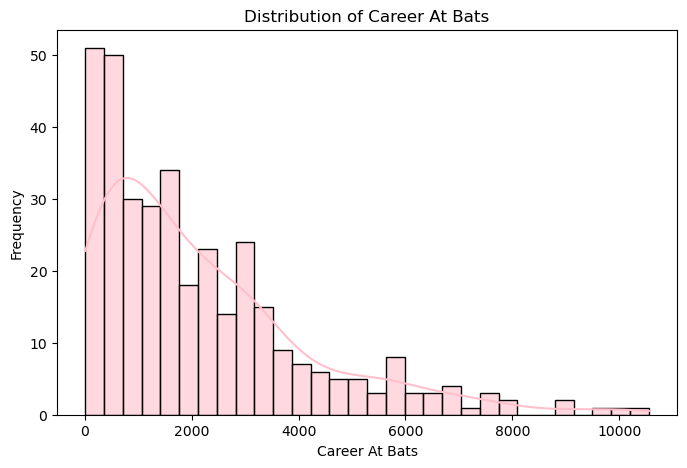

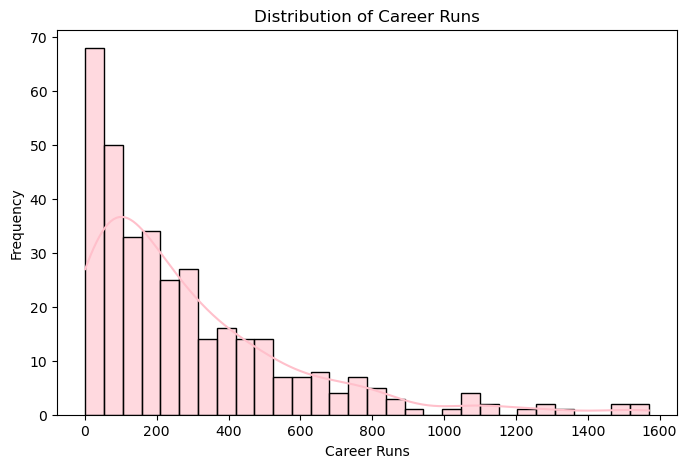

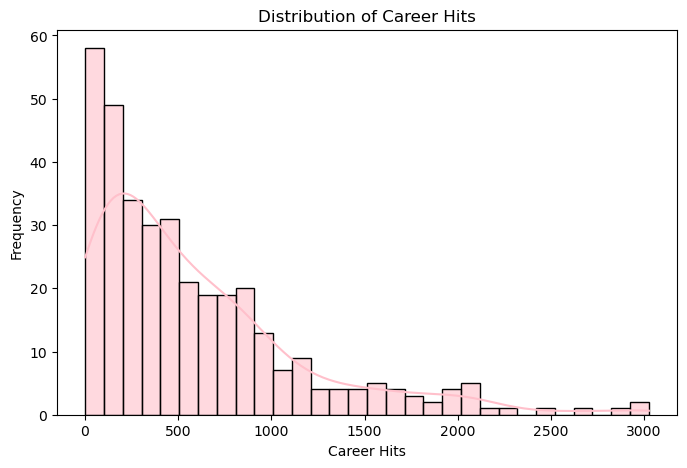

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

continuous_vars = [
    "career_at_bats", "career_runs", "career_hits"
]

# Set up chart
plt.figure(figsize=(12, 8))

# Draw histogram and KDE plot for each variable
for var in continuous_vars:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[var], bins=30, kde=True, color="pink", alpha=0.6)
    plt.title(f"Distribution of {var.replace('_', ' ').title()}")
    plt.xlabel(var.replace('_', ' ').title())
    plt.ylabel("Frequency")
    plt.show()

#### Comments:
- Most of the parameters have a right-skewed distribution, with the majority of players having average or low performance.
- A small number of players have outstanding performance, extending the right tail of the distribution.
      + Career at Bats suggests that extended playing time is rare and limited to top or long-tenured players
      + Career Runs reflects a typical performance gap: few high scorers, many average-level players.
      + Career Hits shows that high consistency and longevity are uncommon in the league.
- This reflects that in professional sports, only a small group of players reach the top, while the majority have average performance.

### B. The relationship of a pair of continuous variables.

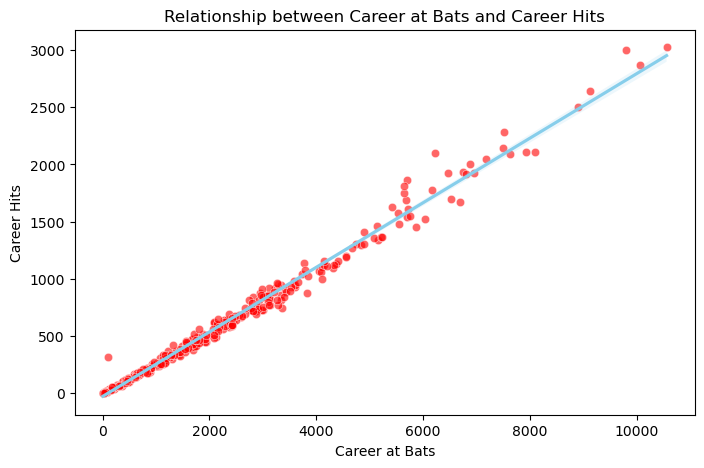

In [28]:
var_x = "career_at_bats"  
var_y = "career_hits"

# Draw a scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df[var_x], y=df[var_y], alpha=0.6, color="red")
sns.regplot(x=df[var_x], y=df[var_y], scatter=False, color="skyblue")

# Set title and label
plt.title(f"Relationship between Career at Bats and Career Hits")
plt.xlabel(f"Career at Bats")
plt.ylabel(f"Career Hits")
plt.show()

#### Comments:
- The relationship between career_at_bats and career_hits shows a strong linear trend.
- The correlation coefficient is highly positive, meaning that more at-bats tend to increase the number of hits.
- The skyblue regression line shows a nearly perfect linear relationship, meaning that players with more at-bats tend to have more hits.
- Some data points are far from the regression line, indicating that there are some outliers – some players may have better or worse than average at-bat rates.

-->There is a clear linear relationship between at-bats and hits, suggesting that more opportunities to play often lead to better performance.

### C. The association b/w a categorical variable and a continuous one.

C:\Users\ACER\AppData\Local\Temp\ipykernel_12096\3695848464.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[cat_var], y=df[cont_var], palette="Oranges")


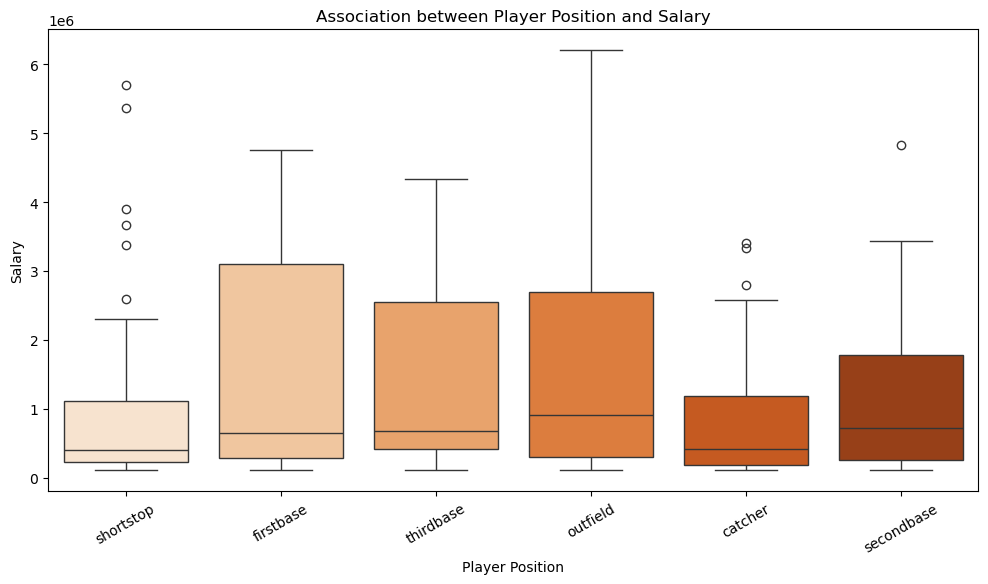

In [31]:
cat_var = "player_position"  # Player position (categorical)
cont_var = "salary"  # Salary (continuous)

# Draw a boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x=df[cat_var], y=df[cont_var], palette="Oranges")

# Set title and label
plt.title(f"Association between Player Position and Salary")
plt.xlabel(f"Player Position")
plt.ylabel(f"Salary")
plt.xticks(rotation=30)
plt.show()

#### Comments:
- Salaries vary significantly between player positions.
- Some positions such as First Base, Outfield, and Third Base have higher average salaries than others.
- Outliers appear at all positions, indicating that some players earn very high salaries compared to the rest.
- Catcher and Second Base have the lowest average salaries, with a narrower salary range than other positions.

--> Position affects player salaries, with First Base, Outfield, and Third Base tending to be higher paid, while Catcher and Second Base have salaries below average.

### D. The relationship between more than two variables, e.g., using semantic mappings.

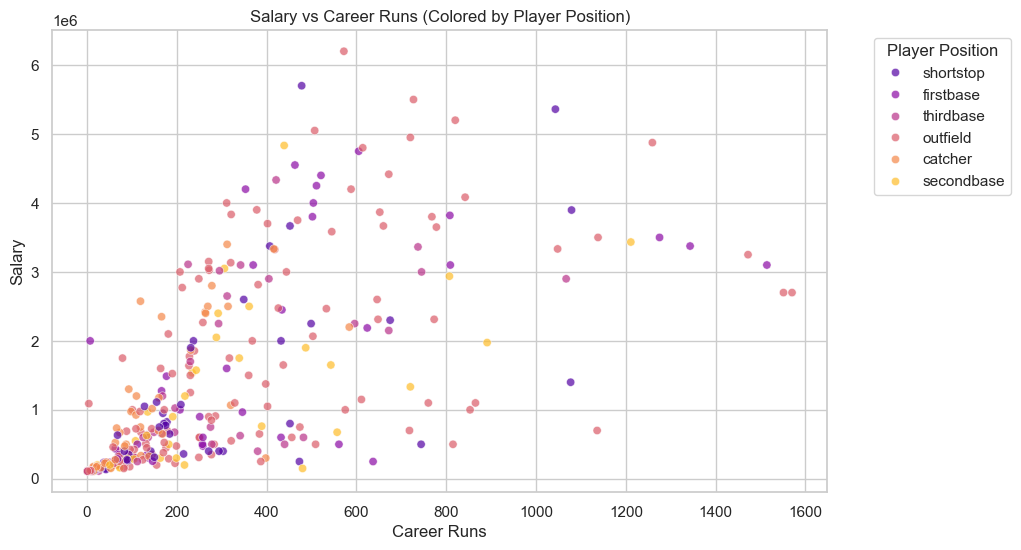

In [34]:
# Set the style for the plots
sns.set(style="whitegrid")

# Scatter Plot with Color Encoding (Salary vs Career Runs, Colored by Player Position)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df['career_runs'], 
    y=df['salary'], 
    hue=df['player_position'],  # Encode player position using color
    palette='plasma', 
    alpha=0.7
)
plt.title('Salary vs Career Runs (Colored by Player Position)')
plt.xlabel('Career Runs')
plt.ylabel('Salary')
plt.legend(title='Player Position', bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.show()

#### Comments:
- Players with more career runs tend to have higher salaries.
- Most players are concentrated under 400 runs and $1.5M salary, indicating average performance and pay.
- Outfielders lead in both runs and salary, Firstbase/Thirdbase are mid to high range, Catchers, Secondbase, Shortstops stay mostly low.
--> There is a clear upward trend between career runs and salary, with outfielders standing out as top earners and performers.

## 4. Display unique values of a categorical variable and their frequencies.

In [37]:
cat_var = "player_position"

# Calculate the frequency of occurrence of each value
table = df[cat_var].value_counts()

# Display frequency table as DataFrame
table_df = table.reset_index()
table_df.columns = [cat_var, "Frequency"]

print(table_df)

  player_position  Frequency
0        outfield        136
1         catcher         52
2       shortstop         49
3       firstbase         45
4      secondbase         36
5       thirdbase         34


## 5.  Build a contingency table of two potentially related categorical variables. Conduct a statistical test of the independence between them and interpret the results.

In [39]:
import scipy.stats as stats

# Select two categorical variables for the contingency table.
cat_var1 = "player_position"
cat_var2 = "race"  

# Create a contingency table
contingency_table = pd.crosstab(df[cat_var1], df[cat_var2])

# Perform Chi-square test to check for independence between two variables
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

# Display results
print("Contingency Table:")
print(contingency_table)
print("\nChi-Square Test Results:")
print(f"Chi-square Statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

# Interpretation of results
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Conclusion: There is a statistically significant relationship between player position and race (rejecting the independence hypothesis).")
else:
    print("Conclusion: There is not enough evidence to conclude that player position and race are related.")

Contingency Table:
race             black  hispanic  white
player_position                        
catcher              2         7     43
firstbase           10         9     26
outfield            72        19     45
secondbase           8         7     21
shortstop            7        19     23
thirdbase            9         3     22

Chi-Square Test Results:
Chi-square Statistic: 76.63
P-value: 0.0000
Degrees of Freedom: 10
Conclusion: There is a statistically significant relationship between player position and race (rejecting the independence hypothesis).


#### Intepret the results:
- Since p-value = 0.0000 < 0.05, we reject the independence hypothesis.
- This means that there is a statistically significant relationship between player position and race.
- Certain positions are more frequently occupied by players from specific racial groups. For example:
    + Outfield has the highest number of Black players (72).
    + Catcher is predominantly White (43).
    + Shortstop has a relatively high number of Hispanic players (19).

## 6. Retrieve one or more subset of rows based on two or more criteria and present descriptive statistics on the subset(s).

In [42]:
# Define new criteria: Select players who play in "firstbase", have more than 100 home runs, and earn more than $3 million
subset_criteria_extended = (df["player_position"] == "firstbase") & (df["career_homeruns"] > 100) & (df["salary"] > 3000000)

# Extract the subset of data based on the new criteria
subset_df_extended = df[subset_criteria_extended]

# Generate descriptive statistics for the new subset
subset_statistics_extended = subset_df_extended.describe()

# Print the results
print("**Descriptive statistics for the subset of players in 'firstbase' position, with more than 100 home runs and a salary above $3 million**:")
print(subset_statistics_extended)

**Descriptive statistics for the subset of players in 'firstbase' position, with more than 100 home runs and a salary above $3 million**:
             salary  team_payroll  years_played  games_played  career_at_bats  \
count  1.100000e+01  1.100000e+01     11.000000     11.000000       11.000000   
mean   3.845000e+06  3.515623e+07     10.727273   1394.000000     5199.000000   
std    5.379359e+05  6.244453e+06      4.540725    643.478049     2574.666542   
min    3.100000e+06  2.455733e+07      7.000000    696.000000     2297.000000   
25%    3.437500e+06  3.076672e+07      7.000000    950.500000     3364.500000   
50%    3.820000e+06  3.594817e+07      9.000000   1028.000000     3780.000000   
75%    4.225000e+06  3.977656e+07     13.500000   1699.500000     6581.500000   
max    4.750000e+06  4.286600e+07     20.000000   2562.000000     9789.000000   

       career_runs  career_hits  career_doubles  career_triples  \
count    11.000000    11.000000       11.000000       11.000000  

#### Comments:
- "Firstbase" players with more than 100 home runs and earning over 3 million generally have long careers (10 years) and high salaries ($3.85 million).
- They exhibit strong batting performance, averaging over 200 home runs and more than 1,500 career hits.
- City demographics suggest they mostly come from areas with a high White population (~77%)

## 7. Conduct a statistical test of the significance of the difference between the means of two subsets of the data and interpret the results.

In [45]:
import scipy.stats as stats

# Define two subsets for comparison
subset1 = df[(df["player_position"] == "firstbase") & (df["career_homeruns"] > 100)]["salary"]
subset2 = df[(df["player_position"] == "outfield") & (df["career_homeruns"] > 100)]["salary"]

# Conduct an independent t-test to compare the means of the two subsets
t_stat, p_value = stats.ttest_ind(subset1, subset2, equal_var=False)

# Display results
print("**Statistical Test for Salary Difference Between 'Firstbase' and 'Outfield' Players with More than 100 Home Runs**")
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
alpha = 0.05  # Significance level
if p_value < alpha:
    print(" Conclusion: There is a statistically significant difference in salaries between 'Firstbase' and 'Outfield' players with more than 100 home runs.")
else:
    print(" Conclusion: There is no significant difference in salaries between 'Firstbase' and 'Outfield' players with more than 100 home runs.")

**Statistical Test for Salary Difference Between 'Firstbase' and 'Outfield' Players with More than 100 Home Runs**
T-statistic: 0.81
P-value: 0.4251
 Conclusion: There is no significant difference in salaries between 'Firstbase' and 'Outfield' players with more than 100 home runs.


#### Comments:
- Since P-value (0.4251) > 0.05, we fail to reject the null hypothesis.
- This means that there is no statistically significant difference in salaries between "Firstbase" and "Outfield" players with more than 100 home runs.
- The difference observed in mean salaries could be due to random variation rather than a true systematic difference.

## 8. Create one or more tables that group the data by a certain categorical variable and display summarized information for each group (e.g., the mean or sum within the group).

In [48]:
# Group the data by player position and summarize key statistics
grouped_stats = df.groupby("player_position").agg(
    mean_salary=("salary", "mean"),
    total_salary=("salary", "sum"),
    mean_home_runs=("career_homeruns", "mean"),
    total_home_runs=("career_homeruns", "sum"),
    mean_games_played=("games_played", "mean"),
    total_games_played=("games_played", "sum")
).reset_index()

# Display the summarized table
print("**Grouped Summary by Player Position**")
print(grouped_stats)

**Grouped Summary by Player Position**
  player_position   mean_salary  total_salary  mean_home_runs  \
0         catcher  8.925192e+05      46411001       26.326923   
1       firstbase  1.586781e+06      71405167       84.911111   
2        outfield  1.539324e+06     209348100       70.625000   
3      secondbase  1.170208e+06      42127499       28.083333   
4       shortstop  1.069211e+06      52391324       26.795918   
5       thirdbase  1.382647e+06      47010000       61.058824   

   total_home_runs  mean_games_played  total_games_played  
0             1369         426.211538               22163  
1             3821         702.511111               31613  
2             9605         706.044118               96022  
3             1011         677.500000               24390  
4             1313         632.918367               31013  
5             2076         646.705882               21988  


#### Comments:
- Firstbase players tend to be among the highest-paid and most productive in terms of home runs.
- Outfielders play the most games and contribute heavily to home run totals.
- Catchers have lower salaries and play fewer games, reflecting the physically demanding nature of their position.

In [50]:
# Group the data by race and summarize key statistics
grouped_stats_race = df.groupby("race").agg(
    mean_salary=("salary", "mean"),
    total_salary=("salary", "sum"),
    mean_home_runs=("career_homeruns", "mean"),
    total_home_runs=("career_homeruns", "sum"),
    mean_games_played=("games_played", "mean"),
    total_games_played=("games_played", "sum")
).reset_index()

# Print the second grouped summary table
print("**Grouped Summary by Race**")
print(grouped_stats_race)

**Grouped Summary by Race**
       race   mean_salary  total_salary  mean_home_runs  total_home_runs  \
0     black  1.654350e+06     178669850       68.231481             7369   
1  hispanic  1.050723e+06      67246267       33.140625             2121   
2     white  1.237650e+06     222776974       53.916667             9705   

   mean_games_played  total_games_played  
0         730.972222               78945  
1         523.109375               33479  
2         637.583333              114765  


#### Comments:
- Black players tend to have the highest salaries and play the most games on average.
- White players have the highest total home runs and total games played, showing a strong long-term presence.
- Hispanic players have the lowest salary, home runs, and games played, suggesting they might have shorter careers or different roles within teams.

## 9. Implement a linear regression model and interpret its output including its accuracy

In [83]:
import statsmodels.api as sm

# Select columns as independent variables and the target variable
selected = ['years_played', 'career_hits', 'career_runs']
target = 'career_triples'

# Drop rows with NaN values
df = df[selected + [target]].dropna()

# Create X (features) and y (target)
X_full = sm.add_constant(df[selected])  # Add an intercept
y = df[target]

# Build an OLS model with all variables
model_full = sm.OLS(y, X_full).fit()

print("🔹 Full model summary:")
print(model_full.summary())

print("\nP-values (Full model):")
print(model_full.pvalues)

🔹 Full model summary:
                            OLS Regression Results                            
Dep. Variable:         career_triples   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     333.0
Date:                Thu, 27 Mar 2025   Prob (F-statistic):          6.71e-102
Time:                        23:04:08   Log-Likelihood:                -1339.0
No. Observations:                 352   AIC:                             2686.
Df Residuals:                     348   BIC:                             2701.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.4039   

In [79]:
# Function for backward elimination
def build_refined_model(X, y, significance_level=0.05):
    while True:
        model = sm.OLS(y, X).fit()
        p_values = model.pvalues[1:]  # Exclude the intercept's p-value

        # Check if all p-values are below the significance level
        if all(p_values < significance_level):
            return model  # Return the model when no variable exceeds the significance threshold

        # Identify the feature with the highest p-value
        worst_feature = p_values.idxmax()
        print(f"Removing feature '{worst_feature}' with p-value = {p_values.max():.4f}")
        
        # Drop that feature from X
        X = X.drop(columns=[worst_feature])

# Apply backward elimination
refined_model = build_refined_model(X_full, y)
print("\n🔹 Refined model summary (after backward elimination):")
print(refined_model.summary())

# Compare Adjusted R²
print(f"\nAdjusted R² (Full): {model_full.rsquared_adj:.4f}")
print(f"Adjusted R² (Refined): {refined_model.rsquared_adj:.4f}")

Removing feature 'years_played' with p-value = 0.6593

🔹 Refined model summary (after backward elimination):
                            OLS Regression Results                            
Dep. Variable:         career_triples   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     500.6
Date:                Thu, 27 Mar 2025   Prob (F-statistic):          2.92e-103
Time:                        23:03:36   Log-Likelihood:                -1339.1
No. Observations:                 352   AIC:                             2684.
Df Residuals:                     349   BIC:                             2696.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------

#### Comments:

1. Model Fit

R-squared = 0.742: About 74.2% of the variation in career_triples is explained by the model.
Adjusted R-squared = 0.740: The model remains strong after adjusting for the number of predictors, indicating good overall fit without overfitting.

2. Coefficients and Significance


Both predictors (career_hits and career_runs) have very low p-values (< 0.001) → statistically significant.

3. Other Model Diagnostics

F-statistic = 500.6 with p < 0.001 → The overall model is highly significant.
Durbin-Watson = 1.974 → Residuals show no sign of autocorrelation.
Condition Number = 1300+ → Slight risk of multicollinearity, but still acceptable.

--> This is a strong and reliable model. It shows that career_hits, years_played and career_runs both have a meaningful impact on the number of career triples. The model explains a large part of the variation and passes important statistical tests, making it suitable for analysis and interpretation.

## Conclusion
This project provides a comprehensive overview of how to explore and analyze data sets using various statistical and visualization methods. Starting with descriptive statistics, I was able to understand the general structure and variability in the data. I carefully handled missing values ​​to ensure that the analysis remained reliable. Visualizations such as histograms, scatter plots, and correlation heat maps helped to clearly demonstrate key patterns and relationships.

I also used statistical tests to test the significance of differences between groups and built simple regression models to determine which variables had the strongest impact on other variables.

Working on this project helped me realize both the possibilities and the difficulties of working with real-world data. I may not have chosen the best techniques every time, but each step taught me something new. It reminded me that data analysis is not just about using the right tools, but also about asking the right questions, thinking clearly, and continuing to improve.